In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras

In [2]:
df = pd.read_csv("1_HousingData.csv", na_values=["NA"])

print(df.head())
print(df.columns)

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90    NaN  36.2  
Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')


In [3]:
# Fill missing values with column mean
df = df.fillna(df.mean())

# Check if any missing values remain
print(df.isnull().sum())

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [4]:
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

In [5]:
print(df.columns)

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
model = keras.Sequential([
    keras.layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(1)
])

c:\Users\Aditya.konde\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss='mse',
    metrics=['mae']
)

In [10]:
history = model.fit(
    X_train, y_train,
    epochs=200,
    validation_split=0.1,
    verbose=1
)

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 528.3975 - mae: 21.1919 - val_loss: 459.2530 - val_mae: 20.0980
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 406.9201 - mae: 18.4977 - val_loss: 331.9127 - val_mae: 16.9516
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 267.3142 - mae: 14.6581 - val_loss: 199.6282 - val_mae: 12.6525
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 144.9554 - mae: 10.0072 - val_loss: 106.9296 - val_mae: 8.2691
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 79.4283 - mae: 7.1238 - val_loss: 70.0801 - val_mae: 5.7648
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 51.5808 - mae: 5.6624 - val_loss: 57.9932 - val_mae: 5.1758
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 37.8229 - mae: 4.7524 - val_loss: 53.4719 - val_mae: 4.9317
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 29.9298 - mae: 4.0374 - val_loss: 54.9198 - val_mae: 5.0657
Epoch 9/200
12/12 ━━━━━━━━━━━

In [11]:
loss, mae = model.evaluate(X_test, y_test)

print("Test Loss (MSE):", loss)
print("Test MAE:", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 14.5676 - mae: 2.5228
Test Loss (MSE): 14.567587852478027
Test MAE: 2.522843837738037


In [12]:
predictions = model.predict(X_test)

for i in range(5):
    print("Actual:", y_test.iloc[i], "Predicted:", predictions[i][0])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Actual: 23.6 Predicted: 29.396305
Actual: 32.4 Predicted: 39.724136
Actual: 13.6 Predicted: 15.387776
Actual: 22.8 Predicted: 24.231693
Actual: 16.1 Predicted: 15.096793


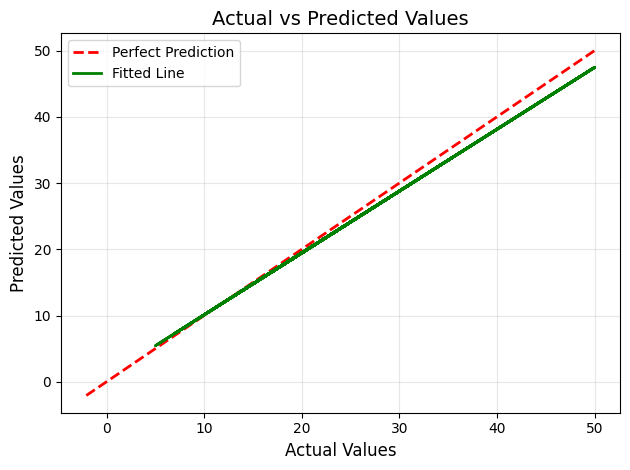

R² Score: 0.8014


In [ ]:
import matplotlib.pyplot as plt
from numpy.polynomial.polynomial import Polynomial

# Get predictions for visualization
y_test_values = y_test.values
predicted_values = predictions.flatten()

# Add regression line (perfect prediction line)
min_val = min(y_test_values.min(), predicted_values.min())
max_val = max(y_test_values.max(), predicted_values.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

# Fit actual regression line through predictions
z = np.polyfit(y_test_values, predicted_values, 1)
p = np.poly1d(z)
plt.plot(y_test_values, p(y_test_values), 'g-', lw=2, label='Fitted Line')

plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.title('Actual vs Predicted Values', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate R-squared
from sklearn.metrics import r2_score
r2 = r2_score(y_test_values, predicted_values)
print(f"R² Score: {r2:.4f}")